In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI

# SQL 쿼리 생성용
model_low_temp = ChatGoogleGenerativeAI(model="gemini-2.0-flash", temperature=0.1)
# 자연어 출력 생성용
model_high_temp = ChatGoogleGenerativeAI(model='gemini-2.0-flash', temperature=0.7)

In [5]:
from typing import Annotated, Literal, TypedDict

from langchain_core.documents import Document
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.vectorstores.in_memory import InMemoryVectorStore
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from langchain_google_genai import GoogleGenerativeAIEmbeddings

embeddings = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")

class State(TypedDict):
    # 대화 기록
    messages: Annotated[list, add_messages]
    # 입력
    user_query: str
    # 출력
    domain: Literal['records', 'insurance']
    documents: list[Document]
    answer: str


class Input(TypedDict):
    user_query: str


class Output(TypedDict):
    documents: list[Document]
    answer: str

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_25532\2415566649.py:142: LangGraphDeprecatedSinceV05: `input` is deprecated and will be removed. Please use `input_schema` instead. Deprecated in LangGraph V0.5 to be removed in V2.0.
  builder = StateGraph(State, input=Input, output=Output)
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_25532\2415566649.py:142: LangGraphDeprecatedSinceV05: `output` is deprecated and will be removed. Please use `output_schema` instead. Deprecated in LangGraph V0.5 to be removed in V2.0.
  builder = StateGraph(State, input=Input, output=Output)


{'router': {'domain': 'insurance', 'messages': [HumanMessage(content='코로나 19도 보험 적용이 되나요?', additional_kwargs={}, response_metadata={}, id='1fade89a-4c10-4f69-91fd-6f9ba30507a1'), AIMessage(content='insurance', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, id='run--38f8fb20-635e-4a71-a6ce-010799514160-0', usage_metadata={'input_tokens': 115, 'output_tokens': 2, 'total_tokens': 117, 'input_token_details': {'cache_read': 0}})]}}
{'retrieve_insurance_faqs': {'documents': [Document(id='ea01efbc-572f-4d21-8112-6b560cf7b8a1', metadata={'domain': 'insurance'}, page_content='# 보험 FAQ\n- Q: 과거에 병력이 있는데 가입가능한가요?\n- A: 치료기간, 현재 상태, 후유증 여부, 연령 등에 따라 다르므로 가입 가능 여부는 가까운 대리점에서 상담 받으세요.\n\n- Q: 보험금 청구 방법은 어떻게 되나요??\n- A: 보험금 청구는 보험금 청구서 작성 후 가까운 대리점을 통해 진행 가능합니다.\n\n- Q: 코로나 19도 보험 적용이 되나요?\n- A: 코로나 19는 보험 대상에 포함되지 않습니다.\n\n- Q: 보험금 지급이 거부되는 경우는 어떤 경우인가요?\n- A: 보험

In [6]:
# 테스트를 위한 샘플 문서
sample_docs = [
    Document(page_content='''# 환자 의료 기록
- 이름: 김일남
- 성별: 남
- 나이: 99세
## 진료 내역
- 2021년 1월 13일: 감기로 인한 발열로 병원 방문
- 2022년 3월 15일: 비염 진단으로 약 처방
- 2022년 5월 20일: 피부과 진료 및 약 처방
- 2022년 6월 10일: 발열 및 기침으로 코로나 검사 및 음성 판정
- 2022년 7월 2일: 코로나 진단 검사 및 양성 판정
    ''',
        metadata={'domain': 'records'}
    ),
    Document(
        page_content='''# 보험 FAQ
- Q: 과거에 병력이 있는데 가입가능한가요?
- A: 치료기간, 현재 상태, 후유증 여부, 연령 등에 따라 다르므로 가입 가능 여부는 가까운 대리점에서 상담 받으세요.

- Q: 보험금 청구 방법은 어떻게 되나요??
- A: 보험금 청구는 보험금 청구서 작성 후 가까운 대리점을 통해 진행 가능합니다.

- Q: 코로나 19도 보험 적용이 되나요?
- A: 코로나 19는 보험 대상에 포함되지 않습니다.

- Q: 보험금 지급이 거부되는 경우는 어떤 경우인가요?
- A: 보험금 지급 거부 사유는 보험 계약서에 명시되어 있습니다. 자세한 사항은 계약서를 참조하세요
        ''',
        metadata={'domain': 'insurance'}
    ),
]

# 벡터 저장소 초기화
medical_records_store = InMemoryVectorStore.from_documents(sample_docs, embeddings)
medical_records_retriever = medical_records_store.as_retriever()

insurance_faqs_store = InMemoryVectorStore.from_documents(sample_docs, embeddings)
insurance_faqs_retriever = insurance_faqs_store.as_retriever()

router_prompt = SystemMessage(
    '''사용자 문의를 어느 도메인으로 라우팅할지 결정하세요. 선택할 수 있는 두 가지 도메인은 다음과 같습니다.
- records: 진단, 치료, 처방과 같은 환자의 의료 기록을 포함합니다.  
- insurance: 보험 정책, 청구, 보장에 대한 자주 묻는 질문을 포함합니다.  

도메인 이름만 출력하세요.'''
)

In [7]:
def router_node(state: State) -> State:
    user_message = HumanMessage(state['user_query'])
    messages = [router_prompt, *state['messages'], user_message]
    res = model_low_temp.invoke(messages)
    return {
        'domain': res.content,
        # 대화 기록 업데이트
        'messages': [user_message, res],
    }


def pick_retriever(
    state: State,
) -> Literal['retrieve_medical_records', 'retrieve_insurance_faqs']:
    if state['domain'] == 'records':
        return 'retrieve_medical_records'
    else:
        return 'retrieve_insurance_faqs'


def retrieve_medical_records(state: State) -> State:
    documents = medical_records_retriever.invoke(state['user_query'])
    return {
        'documents': documents,
    }


def retrieve_insurance_faqs(state: State) -> State:
    documents = insurance_faqs_retriever.invoke(state['user_query'])
    return {
        'documents': documents,
    }


medical_records_prompt = SystemMessage(
    '당신은 유능한 의료 챗봇입니다. 진단, 치료, 처방과 같은 환자의 의료 기록을 기반으로 질문에 답하세요.'
)

insurance_faqs_prompt = SystemMessage(
    '당신은 유능한 의료 보험 챗봇입니다. 보험 정책, 청구 및 보장에 대한 자주 묻는 질문에 답하세요.'
)


def generate_answer(state: State) -> State:
    if state['domain'] == 'records':
        prompt = medical_records_prompt
    else:
        prompt = insurance_faqs_prompt
    messages = [
        prompt,
        *state['messages'],
        HumanMessage(f'Documents: {state['documents']}'),
    ]
    res = model_high_temp.invoke(messages)
    return {
        'answer': res.content,
        # 대화 기록 업데이트
        'messages': res,
    }

In [11]:
builder = StateGraph(State, input_schema=Input, output_schema=Output)
builder.add_node('router', router_node)
builder.add_node('retrieve_medical_records', retrieve_medical_records)
builder.add_node('retrieve_insurance_faqs', retrieve_insurance_faqs)
builder.add_node('generate_answer', generate_answer)
builder.add_edge(START, 'router')
builder.add_conditional_edges('router', pick_retriever)
builder.add_edge('retrieve_medical_records', 'generate_answer')
builder.add_edge('retrieve_insurance_faqs', 'generate_answer')
builder.add_edge('generate_answer', END)

graph = builder.compile()

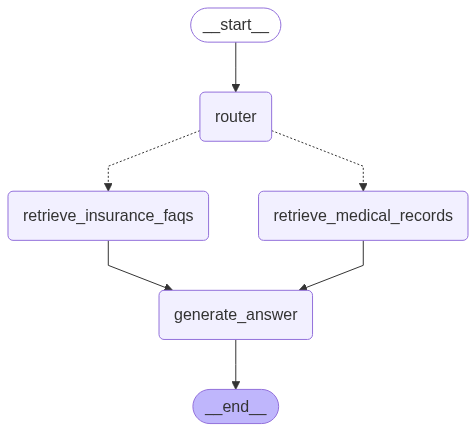

In [16]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))


In [12]:
# 예시
input = {'user_query': '코로나 19도 보험 적용이 되나요?'}
for chunk in graph.stream(input):
    print(chunk)

{'router': {'domain': 'insurance', 'messages': [HumanMessage(content='코로나 19도 보험 적용이 되나요?', additional_kwargs={}, response_metadata={}, id='a67f7315-2460-4fed-a5d1-95f504cbae68'), AIMessage(content='insurance', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, id='run--8902627c-481c-4a64-b236-b57a1f731c1e-0', usage_metadata={'input_tokens': 115, 'output_tokens': 2, 'total_tokens': 117, 'input_token_details': {'cache_read': 0}})]}}
{'retrieve_insurance_faqs': {'documents': [Document(id='81bfba41-48e2-4c23-9f79-a60f3a5551b6', metadata={'domain': 'insurance'}, page_content='# 보험 FAQ\n- Q: 과거에 병력이 있는데 가입가능한가요?\n- A: 치료기간, 현재 상태, 후유증 여부, 연령 등에 따라 다르므로 가입 가능 여부는 가까운 대리점에서 상담 받으세요.\n\n- Q: 보험금 청구 방법은 어떻게 되나요??\n- A: 보험금 청구는 보험금 청구서 작성 후 가까운 대리점을 통해 진행 가능합니다.\n\n- Q: 코로나 19도 보험 적용이 되나요?\n- A: 코로나 19는 보험 대상에 포함되지 않습니다.\n\n- Q: 보험금 지급이 거부되는 경우는 어떤 경우인가요?\n- A: 보험